# Comparing NPE and NPSE on empirical data

In [2]:
!conda activate npse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import pickle
import sbi.utils as utils
import torch
import seaborn as sns
import numpy as np
import sys  
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
# from simulators import WF
import matplotlib as mpl
plt.rcParams['figure.dpi'] = 600

import warnings
warnings.simplefilter('ignore', Warning)


generation = pd.read_csv('empirical_data/Chuong_116_gens.txt').columns
posterior_chuong = pickle.load(open('posteriors/posterior_WF_30000_20.pkl','rb'))


usage: conda [-h] [-v] [--no-plugins] [-V] COMMAND ...
conda: error: argument COMMAND: invalid choice: 'activate' (choose from 'clean', 'compare', 'config', 'create', 'info', 'init', 'install', 'list', 'notices', 'package', 'remove', 'uninstall', 'rename', 'run', 'search', 'update', 'upgrade', 'doctor', 'repoquery', 'env')


In [3]:
# constants
N = int(1e7)
generation = np.array([8, 21, 29, 37, 50, 58, 66, 79, 87, 95, 108, 116]) # from Chuong et al 2024
        

def WF(parameters, seed=None):
    """ CNV evolution simulator
    Simulates CNV and SNV evolution for x generations
    Returns proportion of the population with a CNV for specific generations
    
    Parameters
    -------------------
    N : int = 10M
        population size  
    s_snv : float
        fitness benefit of SNVs  
    m_snv : float 
        probability mutation to SNV   
    generation : np.array, 1d 
        with generations to output
    seed : int
    
    s_cnv : float
        fitness benefit of CNVs  
    m_cnv : float 
        probability mutation to CNV 
    p_0: float
        fraction of population with GAP1 CNV before beginning of experiment
    """
    # CNV parameters
    s_cnv, m_cnv, p_0 = 10**parameters

    # SNV parameters as constants
    s_snv = 1e-3
    m_snv = 1e-5
    
    if seed is not None:
        np.random.seed(seed=seed)
    else:
        np.random.seed()

    
    
    
    # Order is: wt, cnv+, cnv-, snv
    
    w = np.array([1, 1 + s_cnv, 1 + s_cnv, 1 + s_snv], dtype='float64')
    S = np.diag(w)
    
    # make transition rate array
    M = np.array([[1 - m_cnv - m_snv, 0, 0, 0],
                [m_cnv, 1, 0, 0],
                [0, 0, 1, 0],
                [m_snv, 0, 0, 1]], dtype='float64')
    assert np.allclose(M.sum(axis=0), 1)
    
    
    # mutation and selection
    E = M @ S

    # rows are genotypes, p has proportions after initial (unreported) growth
    n = np.zeros(4)
    n[2] = N*p_0 # cnv-
    n[0] = N*(1-p_0) # wt
    
    # follow proportion of the population with CNV
    # here rows will be generation, columns (there is only one) is replicate population
    p_cnv = []
    
    # run simulation to generation 116
    for t in range(int(generation.max()+1)):    
        p = n/N  # counts to frequencies
        p_cnv.append(p[1])  # frequency of reported CNVs
        p = E @ p.reshape((4, 1))  # natural selection + mutation        
        p /= p.sum()  # rescale proportions
        n = np.random.multinomial(N, np.ndarray.flatten(p)) # random genetic drift
    ret = np.transpose(p_cnv)[generation.astype(int)]
    noise = np.random.normal(0,0.02,size=ret.shape)
    return torch.tensor(ret)

def wrapper(simulator, reps, parameters, seed=None):
    rep_1 = simulator(parameters)
    if simulator == WF:
        rep_1 = rep_1.reshape(1,-1)
    out_reps = torch.empty((reps, rep_1.shape[1]))
    out_reps[0,:] = rep_1
    for i in range(1,reps):
        out=simulator(parameters)
        out_reps[i,:] = out
    return out_reps


In [4]:
import sbi
sbi.__version__

'0.24.0'

In [19]:
from sbi.inference import NPSE
from sbi.utils import BoxUniform
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

# Check prior, return PyTorch prior.
prior = BoxUniform(low=torch.tensor([-2, -7, -8]), high=torch.tensor([0, -2, -2]))
prior, num_parameters, prior_returns_numpy = process_prior(prior)

simulator = WF

# Check simulator, returns PyTorch simulator able to simulate batches.
simulator = process_simulator(WF, prior, prior_returns_numpy)

# Consistency check after making ready for sbi.
check_sbi_inputs(simulator, prior)


num_sims = 30_000

theta = prior.sample((num_sims,))
x = simulator(theta)
inference = NPSE(prior, sde_type="ve")
_ = inference.append_simulations(theta, x).train()
posterior_npse = inference.build_posterior()


 Training neural network. Epochs trained: 27

Drawing 1000 posterior samples:   0%|                  | 0/1000 [04:18<?, ?it/s]


 Neural network successfully converged after 875 epochs.

In [25]:
t = prior.sample((1,))[0]
print(t)
x = wrapper(WF, 3, t)
posterior_npse.set_default_x(x).sample((10,), show_progress_bars=False)

tensor([-1.6235, -4.7648, -4.2536])


tensor([[-0.9865, -5.8361, -2.4179],
        [-1.4137, -5.3428, -2.7358],
        [-1.5055, -5.9611, -6.4552],
        [-0.6076, -6.4797, -3.9664],
        [-0.4704, -6.4670, -3.9853],
        [-1.6155, -5.3466, -5.4626],
        [-1.2702, -6.2545, -5.2940],
        [-1.3871, -5.7301, -5.4927],
        [-1.5689, -4.9668, -6.0630],
        [-1.6596, -5.0641, -6.9228]])

In [33]:
theta = torch.tensor(np.array(pd.read_csv('tests/test_thetas.csv', index_col=0).iloc[450:]))

def test_estimator(posterior, theta,output_file_name='test_results.csv', export = False):
    n_samples = 400
    all_samples = torch.empty(len(theta), len(theta[0])*n_samples)
    print(all_samples.shape)
    for i in range(len(theta)):
        true_param = theta[i,:]
        xi = wrapper(simulator=WF,reps=10,parameters=true_param)
        try:
            samps = posterior.set_default_x(xi).sample((n_samples,), show_progress_bars=False)
        except:
            samps = posterior.set_default_x(xi).sample((n_samples,), show_progress_bars=False)
        m = samps.mean(0)
        # m = np.array(posterior.set_default_x(xi).map(num_iter=100))[0]
        all_samples[i,:] = samps.flatten()
        print(m-true_param)
    if export:
        pd.DataFrame(np.array(all_samples)).to_csv(output_file_name)
    return pd.DataFrame(np.array(all_samples))

test_results_npse = test_estimator(posterior_npse, theta, export = True, output_file_name='tests/samples_npse.csv')

torch.Size([50, 1200])
tensor([-0.0267,  0.6489,  3.6399], dtype=torch.float64)
tensor([ 0.0019, -0.0144,  0.4006], dtype=torch.float64)
tensor([-0.0501,  0.0317, -0.6917], dtype=torch.float64)
tensor([0.0632, 0.2256, 1.7328], dtype=torch.float64)


_LinAlgError: linalg.eigh: (Batch element 5169): The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated eigenvalues (error code: 2).

In [6]:
def test_estimator(posterior, X, theta,output_file_name='test_results.csv', export = False):
    output_data = pd.DataFrame(columns = ['s','mu', 'phi'], index = [i for i in range(len(theta))])
    for i in range(len(X)):
        xi = torch.tensor(X[i,:])
        true_param = torch.tensor(theta[i,:])
        samps = posterior.set_default_x(xi).sample((100,))
        m = samps.mean(0)
        # m = np.array(posterior.set_default_x(xi).map(num_iter=100))[0]
        output_data.iloc[i,:] = (m-true_param).numpy()
    if export:
        output_data.to_csv(output_file_name)
    return output_data

test_results_npse = test_estimator(posterior_npse, x, theta, export = False, output_file_name='test_results_npse.csv')

Drawing 100 posterior samples:   0%|          | 0/499 [00:00<?, ?it/s]

Drawing 100 posterior samples:   0%|          | 0/499 [00:00<?, ?it/s]

Drawing 100 posterior samples:   0%|          | 0/499 [00:00<?, ?it/s]

Drawing 100 posterior samples:   0%|          | 0/499 [00:00<?, ?it/s]

Drawing 100 posterior samples:   0%|          | 0/499 [00:00<?, ?it/s]

Drawing 100 posterior samples:   0%|          | 0/499 [00:00<?, ?it/s]

Drawing 100 posterior samples:   0%|          | 0/499 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
def plot_test_results(test_results, ax, label):
    sns.histplot(test_results['s'], ax = ax[0], stat='density', bins=20, label=label)
    sns.histplot(test_results['mu'], ax = ax[1], stat='density', bins=20)
    fig.supxlabel('$log_{10}({}/{True})$')
    ax[0].set_xlabel('s')
    ax[1].set_xlabel('$\mu$')
    ax[0].axvline(0,color='red')
    ax[1].axvline(0,color='red')

fig, ax = plt.subplots(1,2, figsize=(12,8))
plot_test_results(test_results_npe, ax, label='NPE')
plot_test_results(test_results_npse, ax, label='NPSE')
ax[0].legend()

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

...

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

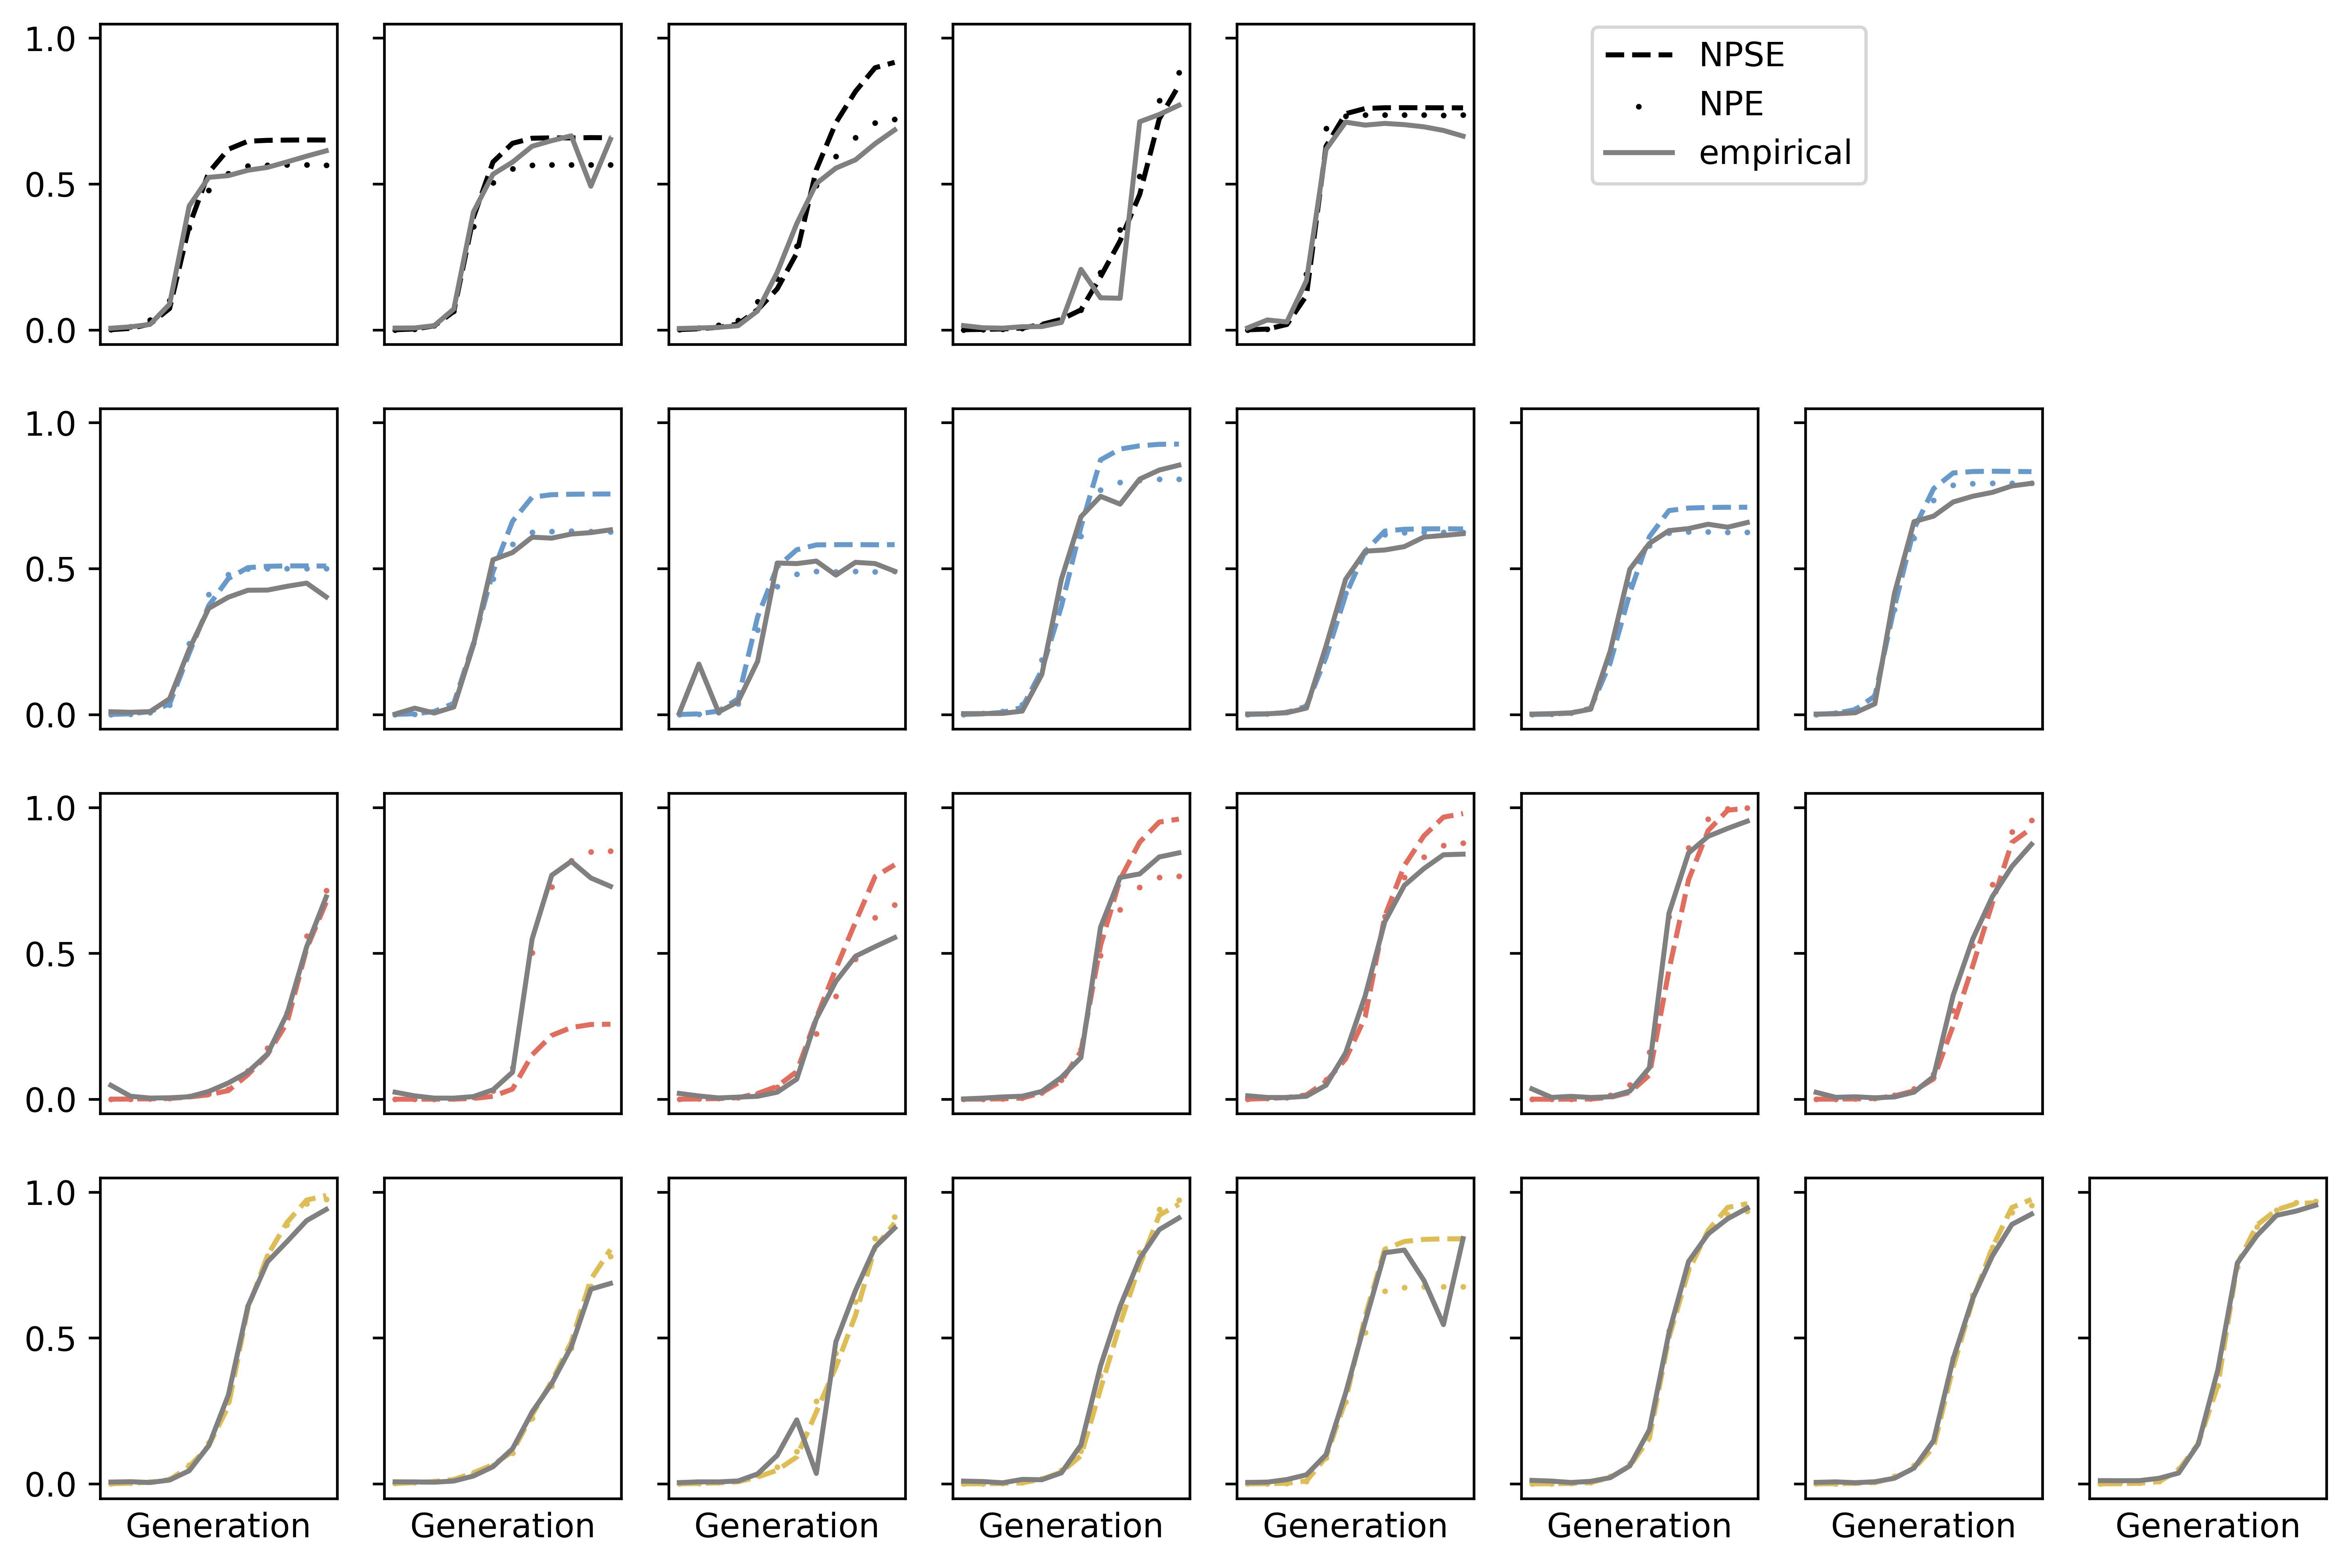

In [31]:
fig, ax = plt.subplots(4,8, tight_layout=True, figsize=(12,8), sharex=True, sharey=True)

lines = ['wt','ltr','ars','all']
rep_colors = {'wt':"black", 'ltr':"#6699cc", 'ars': "#e26d5c", 'all':"#DEBD52", "lauer": "grey"}
label_dict = {'wt': 'Wildtype', 'ltr': 'LTRΔ', 'ars': 'ARSΔ', 'all': 'ALLΔ', 'lauer': 'Lauer'}

sample_means_npse = np.array(pd.read_csv('posteriors/npse_sample_means.csv', index_col=0))


t=0
for i in range(len(lines)):
    line = lines[i]
    amortized_posterior = posterior_chuong
    Xs = pd.read_csv(f'empirical_data/{line}.csv', index_col=0) # observations
    Xs = torch.tensor(np.array(Xs), dtype=torch.float32)
    for j in range(len(Xs)):
        x = Xs[j]
        samps = sample_means_npse[t]
        samps_ = posterior_chuong.sample((100,),x=x).mean(0)
        y, y_ = WF(samps), WF(samps_)
        ax[i,j].plot(generation,y, color=rep_colors[line], ls='--', label='NPSE' if t==4 else '')
        ax[i,j].scatter(generation,y_, color=rep_colors[line], s=0.5, label='NPE' if t==4 else '')
        ax[i,j].plot(generation,x, color='grey', label='empirical' if t==4 else '')
        ax[i,j].set_xticks([])
        ax[-1,j].set_xlabel('Generation')
        t+=1
    for k in range(j+1,8):
            ax[i,k].axis('off')
ax[0,4].legend(loc=(1.5,0.5))